In [34]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [35]:
class BatsmanState(TypedDict):
    
    runs: int
    balls: int
    fours: int
    sixes: int
    
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    
    summary: str

In [36]:
def calculate_strike_rate(state: BatsmanState):
    
    strike_rate = (state['runs']/state['balls']) * 100
    
    
    return {'strike_rate': strike_rate}

In [37]:
def calculate_balls_per_boundary(state: BatsmanState):
    
    balls_per_boundary = state['balls']/(state['fours'] + state['sixes'])
    \
    
    return {'balls_per_boundary': balls_per_boundary}

In [38]:
def calculate_boundary_percentage(state: BatsmanState):
    
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs']) * 100
        
    return {'boundary_percentage': boundary_percent}

In [39]:
def summary(state: BatsmanState):
    
    summary = f'''
        Strike Rate = {state['strike_rate']}
        Balls per boundary = {state['balls_per_boundary']}
        Boundary percentage = {state['boundary_percentage']}
        
    '''
    
    return {'summary': summary}

In [40]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_ball_per_boundary", calculate_balls_per_boundary)
graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)
graph.add_node("summary", summary)


# Edges

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_ball_per_boundary')
graph.add_edge(START, 'calculate_boundary_percentage')

graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_ball_per_boundary', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

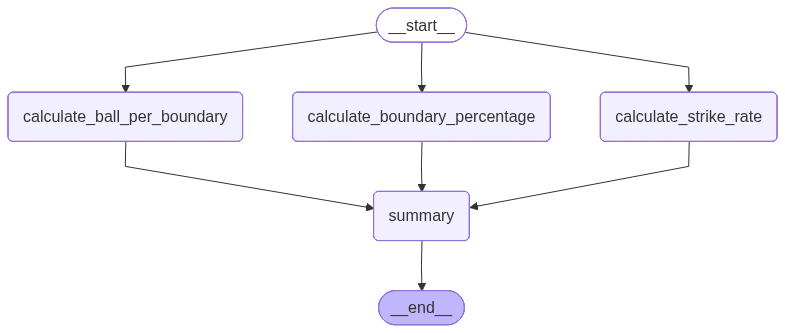

In [41]:
workflow

In [42]:
initial_state = {
    'runs': 100,
    "balls": 50,
    "fours": 10,
    "sixes": 5
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 200.0,
 'balls_per_boundary': 3.3333333333333335,
 'boundary_percentage': 70.0,
 'summary': '\n        Strike Rate = 200.0\n        Balls per boundary = 3.3333333333333335\n        Boundary percentage = 70.0\n\n    '}